# Checkpoint 1 – Quem é o mago mais habilidoso do universo Harry Potter?

**Nível de significância:** α = 0,10

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Guiroselli/cp1Nemec/blob/main/checkpoint_magos.ipynb)

Técnicas usadas (todas das Aulas 1, 2 e 3 de Teste de Hipóteses): teste de **Shapiro**, teste de **Friedman**
(3+ condições pareadas), pós-hoc com **Wilcoxon pareado + correção de Bonferroni** e **teste t pareado (ttest_rel)** no desempate.

## 1. Definição de "mais habilidoso"

Para mim, o mago mais habilidoso é o **mais rápido**: em duelo, missão ou exame, quem conjura primeiro decide o resultado.
Por isso a métrica principal é o **tempo de execução** (`tempo_execucao_s`) – **quanto menor, mais habilidoso**.
É uma variável numérica contínua, adequada aos testes.

**Critérios de desempate** (só se o critério principal não separar os melhores):
1. Maior **Índice de Qualidade (IQ)** = média de precisão, potência e controle;
2. Menor taxa de **dano colateral**.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

ALPHA = 0.10

## 2. Carregando os dados

In [2]:
URL = "https://raw.githubusercontent.com/Guiroselli/cp1Nemec/main/checkpoint_magos_dados.csv"
if os.path.exists("checkpoint_magos_dados.csv"):
    df = pd.read_csv("checkpoint_magos_dados.csv")   # arquivo enviado para o Colab
else:
    df = pd.read_csv(URL)                            # lê direto do GitHub
df.head()

,execucao_id,prova_id,mago,categoria,tarefa,dificuldade,pressao,resistencia_alvo,alvo_movel,contexto,tempo_execucao_s,precisao_pct,potencia_pct,controle_pct,sucesso,dano_colateral
0,E00001,P001,Albus Dumbledore,Ataque,Expelliarmus,1,10,1,0,duelo_real,11.08,83.18,83.76,83.17,1,0
1,E00002,P002,Albus Dumbledore,Ataque,Estupefaca,3,7,9,0,missao,14.97,77.64,76.94,81.93,1,0
2,E00003,P003,Albus Dumbledore,Ataque,Bombarda,4,3,4,0,treino,13.89,79.25,88.36,85.62,1,0
3,E00004,P004,Albus Dumbledore,Ataque,Confringo,4,9,8,0,duelo_real,13.79,85.30,87.36,81.13,0,0
4,E00005,P005,Albus Dumbledore,Ataque,Expelliarmus,2,4,9,1,exame,14.48,81.97,81.01,78.82,1,0


In [3]:
print(df.shape)
print("Magos:", df['mago'].nunique(), "| Provas:", df['prova_id'].nunique())
# Cada prova_id (mesma condição experimental) foi feita pelos 12 magos -> DADOS PAREADOS
df.groupby('prova_id')['mago'].nunique().value_counts()

(1440, 16)
Magos: 12 | Provas: 120


mago
12    120
Name: count, dtype: int64

## 3. Tempo de execução por mago

In [4]:
# Tabela larga: cada linha é uma prova, cada coluna um mago (formato pareado)
tempo = df.pivot(index='prova_id', columns='mago', values='tempo_execucao_s')

resumo = pd.DataFrame({'tempo_media': tempo.mean(), 'tempo_mediana': tempo.median(), 'tempo_desvio': tempo.std()})
resumo = resumo.sort_values('tempo_mediana')
resumo.round(3)

,tempo_media,tempo_mediana,tempo_desvio
mago,,,
Harry Potter,12.506,12.475,1.721
Nymphadora Tonks,12.974,12.905,1.544
Kingsley Shacklebolt,13.040,12.985,1.655
Bellatrix Lestrange,13.030,13.010,1.704
Severus Snape,13.000,13.050,1.687
Lord Voldemort,13.101,13.080,1.723
Filius Flitwick,12.937,13.180,1.708
Gellert Grindelwald,13.149,13.230,1.522
Albus Dumbledore,13.413,13.550,1.659


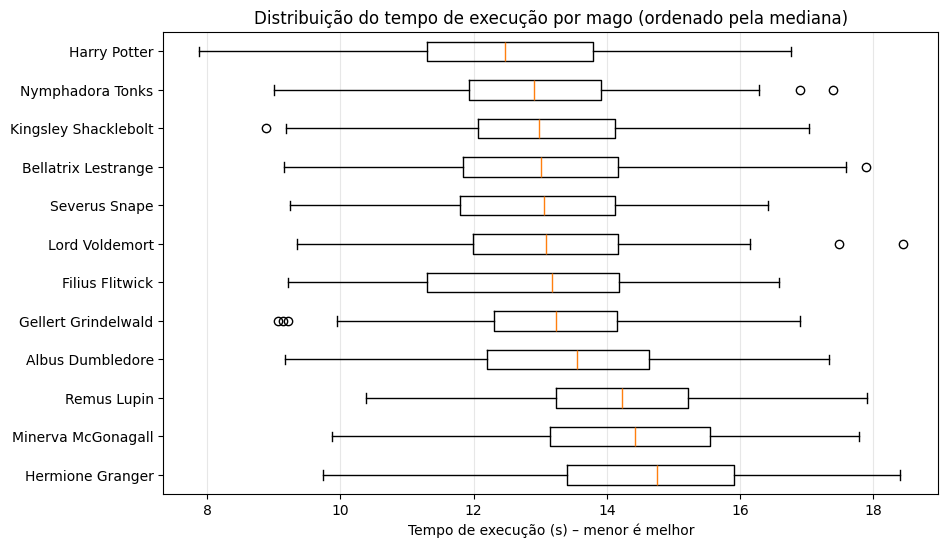

In [5]:
ordem = resumo.index
plt.figure(figsize=(10, 6))
plt.boxplot([tempo[m] for m in ordem], vert=False)
plt.yticks(range(1, len(ordem) + 1), ordem)
plt.gca().invert_yaxis()
plt.xlabel('Tempo de execução (s) – menor é melhor')
plt.title('Distribuição do tempo de execução por mago (ordenado pela mediana)')
plt.grid(axis='x', alpha=.3)
plt.show()

## 4. Estratégia do experimento

1. **Tipo de dado:** os 12 magos fizeram as mesmas 120 provas → **dados pareados** com **3 ou mais condições**.
2. **Pressuposto de normalidade:** teste de **Shapiro** no tempo de cada mago (H0: dados normais).
3. **Teste global:** 12 condições pareadas → **Friedman** (não exige normalidade).
   - H0: as distribuições do tempo dos 12 magos são iguais
   - H1: pelo menos um mago é diferente
4. **Pós-hoc:** comparo o **líder** (menor mediana de tempo) com cada um dos outros 11 usando **Wilcoxon pareado unilateral**
   e corrijo os p-valores com **Bonferroni** (p × 11), para não acumular erro tipo I.
   - H0: o líder não é mais rápido que o mago comparado
   - H1: o líder é mais rápido que o mago comparado
5. Quem **não** for significativamente mais lento que o líder fica **empatado** e vai para o desempate.

### 4.1 Shapiro – normalidade do tempo de cada mago

In [6]:
shapiro = pd.DataFrame({m: stats.shapiro(tempo[m]) for m in tempo}, index=['W', 'p_valor']).T
shapiro['normal?'] = np.where(shapiro['p_valor'] >= ALPHA, 'Sim', 'Não')
shapiro.sort_values('p_valor').round(4)

,W,p_valor,normal?
Filius Flitwick,0.9760,0.0307,Não
Gellert Grindelwald,0.9819,0.1067,Sim
Hermione Granger,0.9871,0.3164,Sim
Severus Snape,0.9879,0.3637,Sim
Minerva McGonagall,0.9885,0.4098,Sim
Bellatrix Lestrange,0.9897,0.5067,Sim
Albus Dumbledore,0.9907,0.5986,Sim
Lord Voldemort,0.9924,0.7629,Sim
Kingsley Shacklebolt,0.9925,0.7687,Sim
Nymphadora Tonks,0.9950,0.9472,Sim


In [7]:
todos_normais = (shapiro['p_valor'] >= ALPHA).all()
print('Todos os magos têm tempo normal?', todos_normais)
print('-> Nem todos são normais e os dados são pareados com 12 condições: usamos Friedman (não paramétrico).')

Todos os magos têm tempo normal? False
-> Nem todos são normais e os dados são pareados com 12 condições: usamos Friedman (não paramétrico).


### 4.2 Friedman – existe diferença entre os magos?

In [8]:
stat, p_friedman = stats.friedmanchisquare(*[tempo[m] for m in tempo])
print(f'Friedman: estatística = {stat:.2f} | p-valor = {p_friedman:.3e}')
print('Rejeita H0: existe diferença de velocidade entre os magos.' if p_friedman < ALPHA
      else 'Não rejeita H0: não há evidência de diferença.')

Friedman: estatística = 342.09 | p-valor = 1.145e-66
Rejeita H0: existe diferença de velocidade entre os magos.


### 4.3 Pós-hoc – líder vs. demais (Wilcoxon pareado + Bonferroni)

In [9]:
lider = resumo.index[0]
n_comp = len(resumo) - 1
print('Líder (menor mediana de tempo):', lider)

linhas = []
for mago in resumo.index[1:]:
    p = stats.wilcoxon(tempo[lider], tempo[mago], alternative='less').pvalue
    p_bonf = min(p * n_comp, 1.0)
    linhas.append({'comparado_com': mago,
                   'dif_mediana_s': (tempo[lider] - tempo[mago]).median(),
                   'p_valor': p, 'p_bonferroni': p_bonf,
                   'decisao': 'Rejeita H0 (líder é mais rápido)' if p_bonf < ALPHA else 'Não rejeita H0 (EMPATE)'})

posthoc = pd.DataFrame(linhas)
posthoc.round(5)

Líder (menor mediana de tempo): Harry Potter


,comparado_com,dif_mediana_s,p_valor,p_bonferroni,decisao
0,Nymphadora Tonks,-0.425,0.00008,0.00086,Rejeita H0 (líder é mais rápido)
1,Kingsley Shacklebolt,-0.560,0.00000,0.00005,Rejeita H0 (líder é mais rápido)
2,Bellatrix Lestrange,-0.620,0.00005,0.00050,Rejeita H0 (líder é mais rápido)
3,Severus Snape,-0.705,0.00031,0.00338,Rejeita H0 (líder é mais rápido)
4,Lord Voldemort,-0.585,0.00001,0.00015,Rejeita H0 (líder é mais rápido)
5,Filius Flitwick,-0.525,0.00098,0.01081,Rejeita H0 (líder é mais rápido)
6,Gellert Grindelwald,-0.610,0.00000,0.00001,Rejeita H0 (líder é mais rápido)
7,Albus Dumbledore,-0.960,0.00000,0.00000,Rejeita H0 (líder é mais rápido)
8,Remus Lupin,-1.770,0.00000,0.00000,Rejeita H0 (líder é mais rápido)
9,Minerva McGonagall,-1.755,0.00000,0.00000,Rejeita H0 (líder é mais rápido)


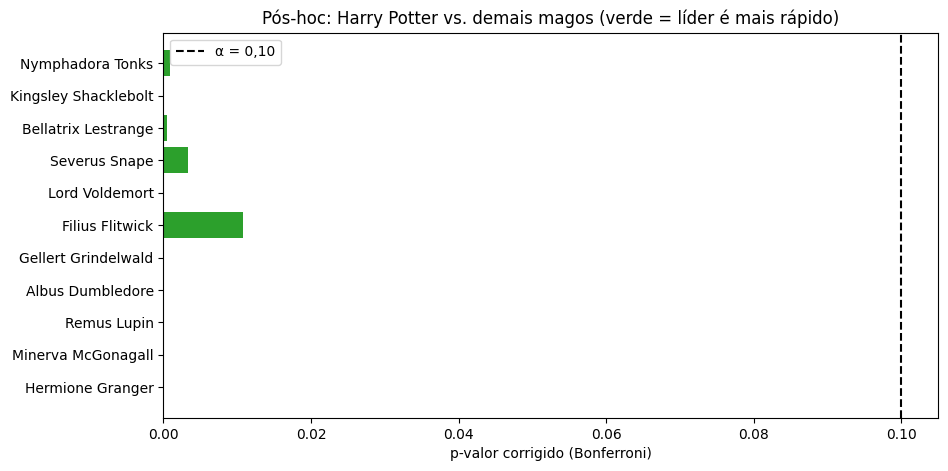

Empatados no critério principal: ['Harry Potter']


In [10]:
plt.figure(figsize=(10, 5))
cores = ['tab:green' if p < ALPHA else 'tab:red' for p in posthoc['p_bonferroni']]
plt.barh(posthoc['comparado_com'], posthoc['p_bonferroni'], color=cores)
plt.axvline(ALPHA, color='k', ls='--', label='α = 0,10')
plt.gca().invert_yaxis()
plt.xlabel('p-valor corrigido (Bonferroni)')
plt.title(f'Pós-hoc: {lider} vs. demais magos (verde = líder é mais rápido)')
plt.legend()
plt.show()

empatados = [lider] + posthoc.loc[posthoc['p_bonferroni'] >= ALPHA, 'comparado_com'].tolist()
print('Empatados no critério principal:', empatados)

## 5. Desempate (aplicado apenas se houver empate)

Sub-critério 1: **Índice de Qualidade (IQ)**. Dados pareados: Shapiro na diferença → se normal, **teste t pareado**; senão, **Wilcoxon pareado**.
Sub-critério 2: menor taxa de dano colateral.

In [11]:
df['IQ'] = df[['precisao_pct', 'potencia_pct', 'controle_pct']].mean(axis=1)
iq = df.pivot(index='prova_id', columns='mago', values='IQ')

vencedor = lider
if len(empatados) == 1:
    print(f'Não houve empate: {lider} foi significativamente mais rápido que todos os outros 11 magos.')
elif len(empatados) == 2:
    a, b = empatados
    dif = iq[a] - iq[b]
    if stats.shapiro(dif).pvalue >= ALPHA:
        p = stats.ttest_rel(iq[a], iq[b]).pvalue
    else:
        p = stats.wilcoxon(iq[a], iq[b]).pvalue
    print(f'Desempate por IQ: p = {p:.5f}')
    if p < ALPHA:
        vencedor = a if iq[a].mean() > iq[b].mean() else b
    else:
        vencedor = df[df['mago'].isin(empatados)].groupby('mago')['dano_colateral'].mean().idxmin()
else:
    print('Mais de dois empatados: repetir Friedman + pós-hoc entre eles usando o IQ.')

print('\nMAGO MAIS HABILIDOSO:', vencedor)

Não houve empate: Harry Potter foi significativamente mais rápido que todos os outros 11 magos.

MAGO MAIS HABILIDOSO: Harry Potter


## 6. Conclusão

- **Shapiro:** nem todos os magos têm tempo normal (Filius Flitwick, p ≈ 0,03 < 0,10).
- **Friedman:** p ≈ 1e-66 → existe diferença de velocidade entre os magos.
- **Pós-hoc (Wilcoxon pareado + Bonferroni):** o líder, **Harry Potter** (mediana 12,5 s), foi significativamente mais rápido
  que **todos os outros 11 magos** (maior p corrigido ≈ 0,011, contra Filius Flitwick).
- Não houve empate, então os sub-critérios não foram necessários.

**Resultado: Harry Potter é o mago mais habilidoso** segundo o meu critério. Curiosamente, ele é o último colocado em
qualidade técnica e taxa de sucesso – o "mais fraco" nas outras métricas é o mais habilidoso quando o que importa é a rapidez.